# EDA with Data Visualization

**Purpose:** visualize launch-site activity, orbit-level success, payload relationships, and change over time.

In [1]:
from pathlib import Path
def resolve_data(filename):
    candidates = [Path("data")/filename, Path("../data")/filename]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(filename)

import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv(resolve_data("spacex_launch_data.csv"))
df.head()


,FlightNumber,LaunchSite,Orbit,PayloadMass,Class,Year
0,1,CCAFS SLC 40,LEO,6123,0,2010
1,2,CCAFS SLC 40,GTO,4535,1,2012
2,3,KSC LC 39A,ISS,5300,1,2014
3,4,VAFB SLC 4E,SSO,4750,1,2015
4,5,CCAFS SLC 40,LEO,6200,1,2016


## Launch count by site

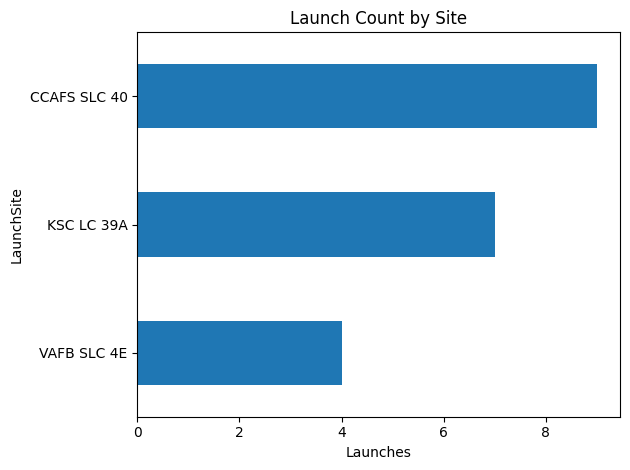

In [2]:
ax=df.groupby("LaunchSite").size().sort_values().plot(kind="barh", title="Launch Count by Site")
ax.set_xlabel("Launches")
plt.tight_layout()
plt.show()


## Landing success rate by orbit

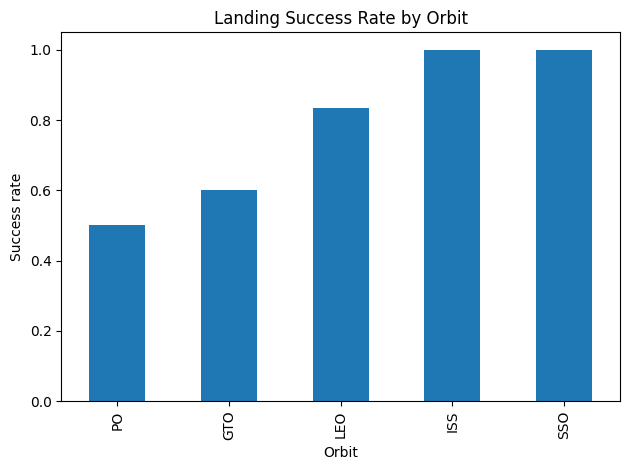

In [3]:
ax=df.groupby("Orbit")["Class"].mean().sort_values().plot(kind="bar", title="Landing Success Rate by Orbit")
ax.set_ylabel("Success rate")
ax.set_ylim(0,1.05)
plt.tight_layout()
plt.show()


## Payload mass and flight number versus landing outcome

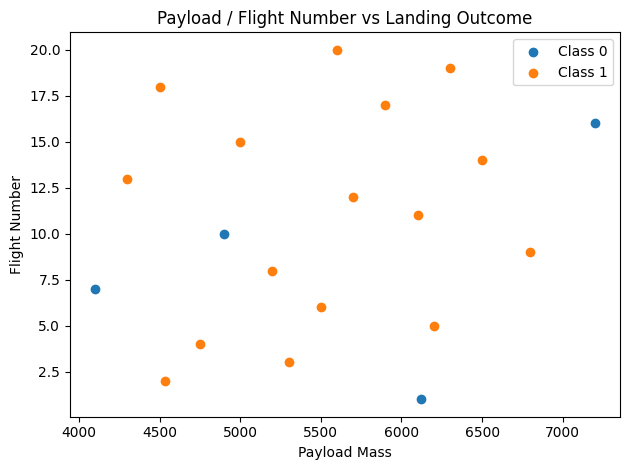

In [4]:
for outcome,g in df.groupby("Class"):
    plt.scatter(g["PayloadMass"],g["FlightNumber"],label=f"Class {outcome}")
plt.xlabel("Payload Mass")
plt.ylabel("Flight Number")
plt.title("Payload / Flight Number vs Landing Outcome")
plt.legend()
plt.tight_layout()
plt.show()


## Landing-success trend by year

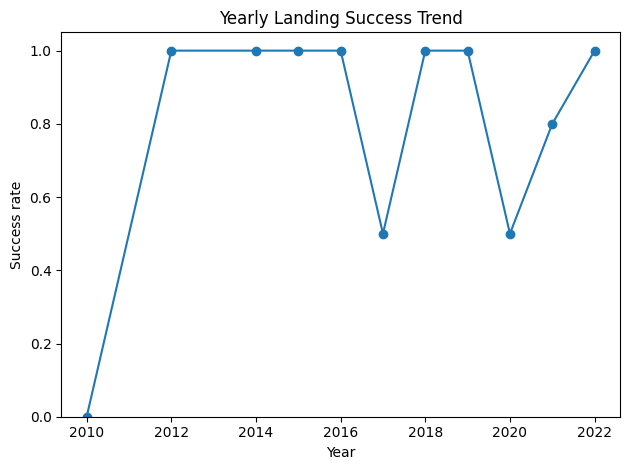

In [5]:
yearly=df.groupby("Year")["Class"].mean()
yearly.plot(marker="o", title="Yearly Landing Success Trend")
plt.ylabel("Success rate")
plt.ylim(0,1.05)
plt.tight_layout()
plt.show()


## EDA insight

The visual analysis shows that launch activity and historical landing outcomes differ across mission categories, supporting the use of site/orbit/payload/time features in classification.